In [42]:
# Predicting Diabetes using Machine learning
# 1.Import Libraries

import os
import shutil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import platform
import joblib

# Libraries using Create Model
from sklearn.model_selection import train_test_split,ShuffleSplit,cross_val_score
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score,accuracy_score,confusion_matrix,classification_report
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV


# Make wide table easir to read
#pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)

In [ ]:
# 2.Mount the Google Drive
from google.colab import drive
drive.mount('..../drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# 3.Load the raw dataset
df = pd.read_csv(".../CDC_Diabetes.csv")

#3a.Dataset shape
print('Dataset Loaded Successfullly.')
print('Shape:',df.shape)
display(df.head())


Dataset Loaded Successfullly.
Shape: (253680, 22)


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
0,1,1,1,40,1,0,0,0,0,1,0,1,0,5,18,15,1,0,9,4,3,0
1,0,0,0,25,1,0,0,1,0,0,0,0,1,3,0,0,0,0,7,6,1,0
2,1,1,1,28,0,0,0,0,1,0,0,1,1,5,30,30,1,0,9,4,8,0
3,1,0,1,27,0,0,0,1,1,1,0,1,0,2,0,0,0,0,11,3,6,0
4,1,1,1,24,0,0,0,1,1,1,0,1,0,2,3,0,0,0,11,5,4,0


In [45]:
#Get the Dataset detail
#3b. Dataset Information

print ('======DataSet Information=====')
df.info()

======DataSet Information=====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype
---  ------                --------------   -----
 0   HighBP                253680 non-null  int64
 1   HighChol              253680 non-null  int64
 2   CholCheck             253680 non-null  int64
 3   BMI                   253680 non-null  int64
 4   Smoker                253680 non-null  int64
 5   Stroke                253680 non-null  int64
 6   HeartDiseaseorAttack  253680 non-null  int64
 7   PhysActivity          253680 non-null  int64
 8   Fruits                253680 non-null  int64
 9   Veggies               253680 non-null  int64
 10  HvyAlcoholConsump     253680 non-null  int64
 11  AnyHealthcare         253680 non-null  int64
 12  NoDocbcCost           253680 non-null  int64
 13  GenHlth               253680 non-null  int64
 14  MentHlth              253680 non-null  int64
 15  Phy

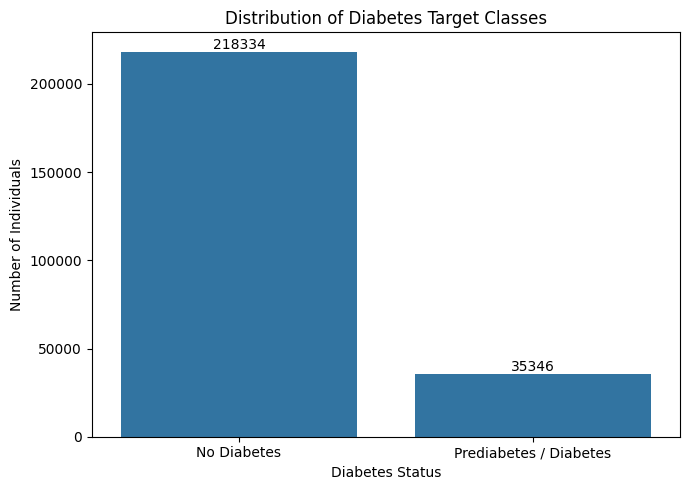

In [78]:
#Target Class Distribution - Bar Chart

plt.figure(figsize=(7,5))

ax = sns.countplot(
    data=df,
    x="Diabetes_binary"
)

plt.title("Distribution of Diabetes Target Classes")
plt.xlabel("Diabetes Status")
plt.ylabel("Number of Individuals")

plt.xticks(
    [0, 1],
    ["No Diabetes", "Prediabetes / Diabetes"]
)

# Add values on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%d')

plt.tight_layout()
plt.show()

In [46]:
# 4.Prepare the Payload_Text (contains CDC_Diabetes_Overview)send to LLM

payload_text =''
#Shape
payload_text += '=======Shape======\n'
payload_text += 'Rows: ' + str(df.shape[0])+ '\n'
payload_text += 'Columns: ' + str(df.shape[1])+ '\n\n'

#List of Columns and DataTypes
payload_text += '=======Columns and DataTypes======\n'
payload_text += df.dtypes.to_string()+ '\n\n'

# Numeric Summary
payload_text += '=======Numeric Summary=====\n'
numeric_summary = df.describe(include='number').round(2)
payload_text += numeric_summary.to_string()+ '\n\n'

# Categorical Summary
payload_text += '\n=======Categorical Summary=====\n'

# Select object and category column types
cat_df = df.select_dtypes(include=['object', 'category'])

if not cat_df.empty:
    categorical_summary = cat_df.describe()
    payload_text += categorical_summary.to_string() + '\n\n'
else:
    payload_text += "No categorical columns found in DataFrame.\n\n"

# Missing Values
payload_text += '=======Missing Values=====\n'
missing_values =pd.DataFrame()
missing_values['missing_count'] = df.isnull().sum()
missing_values['missing_percentage'] = (df.isna().sum() /len(df) * 100).round(2)
payload_text += missing_values.to_string()+ '\n\n'

# Unique Values per column
payload_text += '=======Unique Values per column=====\n'
unique_values = pd.DataFrame()
unique_values['unique_count'] = df.nunique(dropna=False)
payload_text += unique_values.to_string()+ '\n\n'

# Correlation between Numeric Columns
payload_text += '=======Correlation between Numeric Columns=====\n'
correlation_matrix = df.corr(numeric_only=True).round(2)
payload_text += correlation_matrix.to_string()+ '\n\n'

# Duplicate Rows
payload_text += '=======Duplicate Rows=====\n'
#payload_text += 'Duplicate Rows: ' + str(df.duplicated().sum()) + '\n\n'
duplicate_count = df.duplicated().sum()
total_rows = len(df)
duplicate_percentage = (duplicate_count / total_rows) * 100
payload_text += f"Total Rows           : {total_rows:,}\n"
payload_text += f"Duplicate Rows       : {duplicate_count:,}\n"
payload_text += f"Duplicate Percentage : {duplicate_percentage:.2f}%\n\n"



#Display
print(payload_text)

=======Shape======
Rows: 253680
Columns: 22

=======Columns and DataTypes======
HighBP                  int64
HighChol                int64
CholCheck               int64
BMI                     int64
Smoker                  int64
Stroke                  int64
HeartDiseaseorAttack    int64
PhysActivity            int64
Fruits                  int64
Veggies                 int64
HvyAlcoholConsump       int64
AnyHealthcare           int64
NoDocbcCost             int64
GenHlth                 int64
MentHlth                int64
PhysHlth                int64
DiffWalk                int64
Sex                     int64
Age                     int64
Education               int64
Income                  int64
Diabetes_binary         int64

=======Numeric Summary=====
          HighBP   HighChol  CholCheck        BMI     Smoker     Stroke  HeartDiseaseorAttack  PhysActivity     Fruits    Veggies  HvyAlcoholConsump  AnyHealthcare  NoDocbcCost    GenHlth   MentHlth   PhysHlth   DiffWalk        Sex

In [47]:
# 5.Set Up API connection
from google.colab import userdata
from openai import OpenAI
client = OpenAI(
    api_key=userdata.get('OPENAI_API_KEY')
)



In [48]:
# 6.Ask LLM to review data quality using payload
quality_prompt = f"""p
You are helping the data analyst to prepare the CDC diabetes dataset for modeling to predict the diabetes possibilities.

Dataset:
{payload_text}

Task:
1. List all the data quality issue and modelling readiness issues.
2. Suggest action to remedy the issues
3. Provide the corresponding executable Python code for fix the issues.

Important:
-Do not assume extrnal knowledge.
-All the columns datatypes are int64. Do not change the datatypes.
-Do not say to drop a column just because it is listed as a warning.
-Keep the answer concise.
"""
#print(quality_prompt)

response = client.responses.create(
    model="gpt-5-mini",
    input=quality_prompt,
)
print(response.output_text)

Summary of issues (data quality + modeling readiness)
1. Duplicate rows: 24,206 duplicates (~9.5%).
2. Class imbalance: Diabetes_binary mean ≈ 0.14 (positive class ~14%).
3. Outliers / extreme values: BMI (min 12, max 98) — likely outliers; MentHlth/PhysHlth have wide ranges (0–30) but are plausible.
4. Near-zero / low-variance features: CholCheck (~96% one value), AnyHealthcare (~95% one value) — limited information.
5. Multicollinearity / highly correlated predictors: GenHlth correlates strongly with PhysHlth, DiffWalk, etc. (VIF risk).
6. All columns are int64 (OK for storage) but many models expect floats and scaling — do not change original dtypes; use modeling pipelines to scale/transform at fit time.
7. No missing values (good).
8. Potential leakage or domain concerns cannot be automatically ruled out — investigate feature semantics before final modeling.

Recommended actions (concise)
- Remove exact duplicate rows (unless duplicates are meaningful for your analysis).
- Handle o

=======Duplicate Rows=====
Shape before remove duplicate: (253680, 22)
duplicate rows: 24206 (9.54%)
Shape after Remove duplicate: (229474, 22)


======Missing Values=====
No missing values found.

=======Classify features & Min and Max value for each features==============

                     Data Type  Min  Max  Unique Variable Type Check Outliers?
HighBP                   int64    0    1       2        Binary              No
HighChol                 int64    0    1       2        Binary              No
CholCheck                int64    0    1       2        Binary              No
BMI                      int64   12   98      84       Numeric             Yes
Smoker                   int64    0    1       2        Binary              No
Stroke                   int64    0    1       2        Binary              No
HeartDiseaseorAttack     int64    0    1       2        Binary              No
PhysActivity             int64    0    1       2        Binary              No
Fruits       

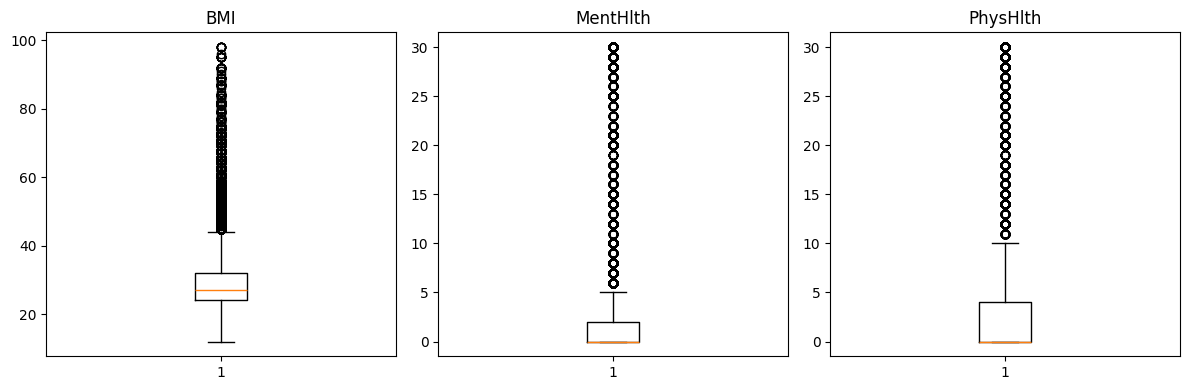

In [88]:
#7. Data Cleaning
# 7a. #Inspect and remove duplicate rows
#Issue: Duplicate rows (~9.5% duplicates) - Risk: Inflated sample size, biased metrics.- Remedy: Inspect and drop exact duplicates.

# basic checks

print ('=======Duplicate Rows=====')
print("Shape before remove duplicate:", df.shape)
n_dupes = df.duplicated().sum()
print("duplicate rows:", n_dupes, f"({n_dupes/len(df):.2%})")

# inspect a few duplicate groups
dup_examples = df[df.duplicated(keep=False)].sort_values(by=list(df.columns))
#print(dup_examples)

# Remove the duplicate rows
df_copy = df.drop_duplicates().reset_index(drop=True)
print("Shape after Remove duplicate:", df_copy.shape)
print("\n")

# 7b. Find Missing Values
print ('======Missing Values=====')
missing_values =df_copy.isna().sum()

if missing_values.sum() == 0:
  print("No missing values found.")
else:
  print("Missing values found:")
  print(missing_values)

# 7c. Classify the features  & Find Min and Max value for each features
print("\n=======Classify features & Min and Max value for each features==============\n")
summary = pd.DataFrame({
    "Data Type": df_copy.dtypes,
    "Min": df_copy.min(),
    "Max": df_copy.max(),
    "Unique": df_copy.nunique()
})

# Define variable groups
binary_cols = [
    'HighBP','HighChol','CholCheck','Smoker','Stroke',
    'HeartDiseaseorAttack','PhysActivity','Fruits',
    'Veggies','HvyAlcoholConsump','AnyHealthcare',
    'NoDocbcCost','DiffWalk','Sex','Diabetes_binary'
]
ordinal_cols = ['Age','Education','Income','GenHlth']
numeric_cols  = ['BMI','MentHlth','PhysHlth']
# Function to classify variables
def variable_type(col):
    if col in binary_cols:
        return "Binary"
    elif col in ordinal_cols:
        return "Ordinal"
    elif col in numeric_cols:
        return "Numeric"
    else:
        return "Unknown"

summary["Variable Type"] = [
    variable_type(col) for col in summary.index
]
summary["Check Outliers?"] = summary["Variable Type"].map({
    "Binary": "No",
    "Ordinal": "No",
    "Numeric": "Yes"
})
print(summary)


#7d. IQR Method
print("\n===========IQR Method=======\n")
columns = ['BMI', 'MentHlth', 'PhysHlth']

for col in columns:

    Q1 = df_copy[col].quantile(0.25)
    Q3 = df_copy[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df_copy[
        (df_copy[col] < lower) |
        (df_copy[col] > upper)
    ]

    print("=" * 40)
    print(f"{col}")
    print(f"Lower Bound : {lower:.2f}")
    print(f"Upper Bound : {upper:.2f}")
    print(f"Potential Outliers : {len(outliers)}")

# 7e. Detect Outliers
print("\n===================describe======================\n")
print(df_copy[['BMI', 'MentHlth', 'PhysHlth']].describe().round(2))

print("\n===========Potential Outliers in Health-Related Numerical Variables=======\n")
columns = ['BMI', 'MentHlth', 'PhysHlth']

#plt.title("Potential Outliers in Health-Related Numerical Variables")
plt.figure(figsize=(12,4))

for i, col in enumerate(columns, 1):
    plt.subplot(1,3,i)
    plt.boxplot(df_copy[col])
    plt.title(col)

plt.tight_layout()
plt.show()

# 7f.Feature Engineering -
# No additional feature engineering was performed because all predictor variables were already well-defined and appropriately encoded. Binary variables were stored as 0/1,
# ordinal variables used meaningful ordered categories, and numeric variables could be used directly for modeling.



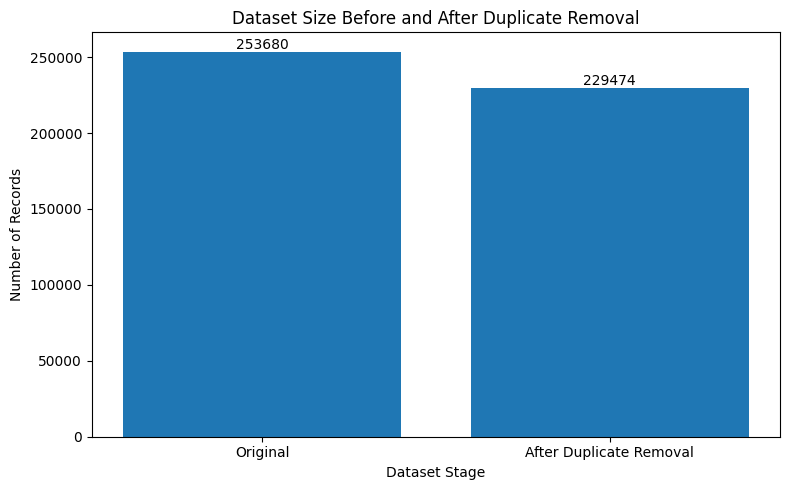

In [82]:
#Dataset Size Before and After Duplicate Removal
records = {
    "Original": len(df),
    "After Duplicate Removal": len(df_copy)
}

plt.figure(figsize=(8,5))

bars = plt.bar(
    records.keys(),
    records.values()
)

plt.title("Dataset Size Before and After Duplicate Removal")
plt.xlabel("Dataset Stage")
plt.ylabel("Number of Records")

plt.bar_label(bars, fmt='%d')

plt.tight_layout()
plt.show()



##Exploratory Data Analysis (EDA)
EDA was performed to identify patterns and relationships between demographic, lifestyle, health-related indicators and the diabetes target.

Since the target distribution was already presented in the Dataset Overview section, the EDA focuses on selected predictors that are relevant to the modelling objective.

The analysis examines General Health, BMI, Age, High Blood Pressure and Physical Health to understand how these variables differ across the two diabetes target classes.

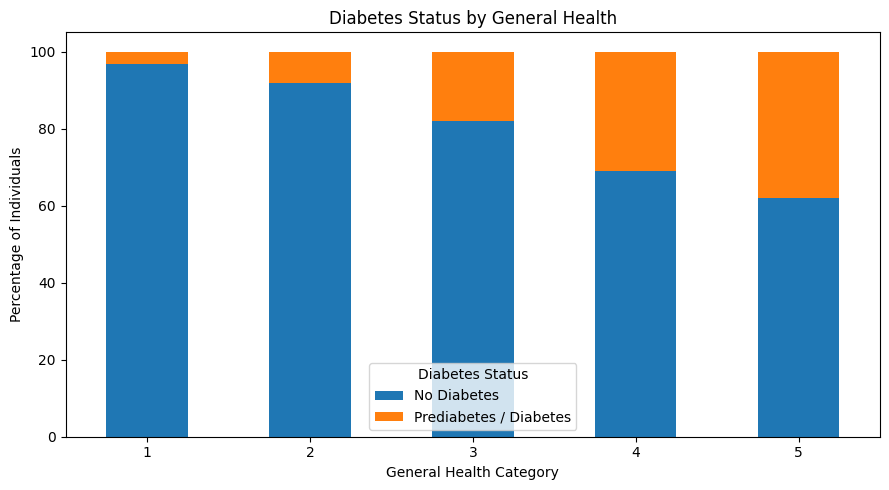

In [91]:
#EDA Chart 1 — Diabetes Status by General Health - Calculate percentage distribution of diabetes status within each GenHlth category
genhlth_pct = pd.crosstab(
    df_copy["GenHlth"],
    df_copy["Diabetes_binary"],
    normalize="index"
) * 100

# Rename columns
genhlth_pct.columns = [
    "No Diabetes",
    "Prediabetes / Diabetes"
]

# Plot
ax = genhlth_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 5)
)

plt.title("Diabetes Status by General Health")
plt.xlabel("General Health Category")
plt.ylabel("Percentage of Individuals")
plt.xticks(rotation=0)
plt.legend(title="Diabetes Status")

plt.tight_layout()
plt.show()

/tmp/ipykernel_2003/1945343178.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


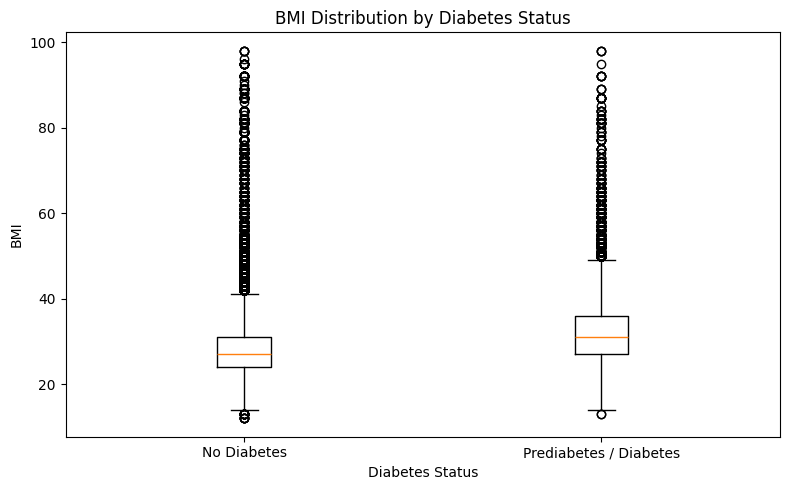

In [93]:
#EDA Chart 2 — BMI Distribution by Diabetes Status
plt.figure(figsize=(8, 5))

plt.boxplot(
    [
        df_copy.loc[
            df_copy["Diabetes_binary"] == 0,
            "BMI"
        ],
        df_copy.loc[
            df_copy["Diabetes_binary"] == 1,
            "BMI"
        ]
    ],
    labels=[
        "No Diabetes",
        "Prediabetes / Diabetes"
    ]
)

plt.title("BMI Distribution by Diabetes Status")
plt.xlabel("Diabetes Status")
plt.ylabel("BMI")

plt.tight_layout()
plt.show()

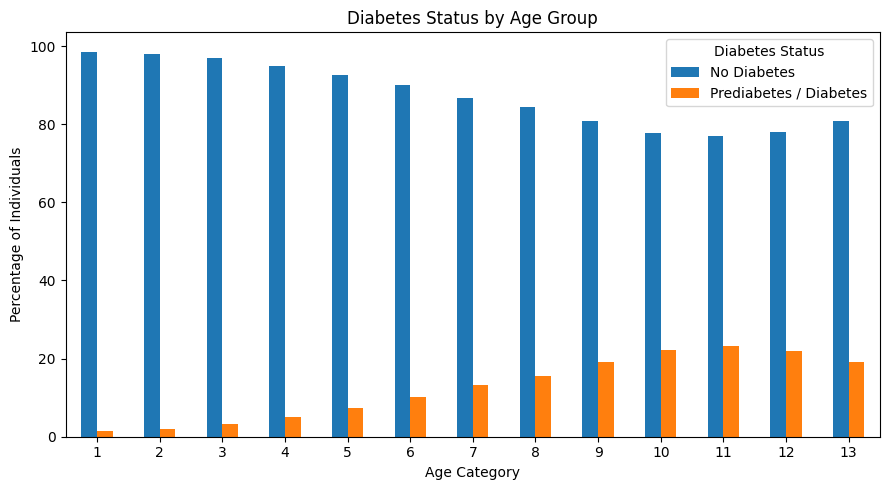

In [95]:
#EDA Chart 3 — Diabetes Status by Age Group
age_pct = pd.crosstab(
    df_copy["Age"],
    df_copy["Diabetes_binary"],
    normalize="index"
) * 100

age_pct.columns = [
    "No Diabetes",
    "Prediabetes / Diabetes"
]

ax = age_pct.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Diabetes Status by Age Group")
plt.xlabel("Age Category")
plt.ylabel("Percentage of Individuals")
plt.xticks(rotation=0)
plt.legend(title="Diabetes Status")

plt.tight_layout()
plt.show()

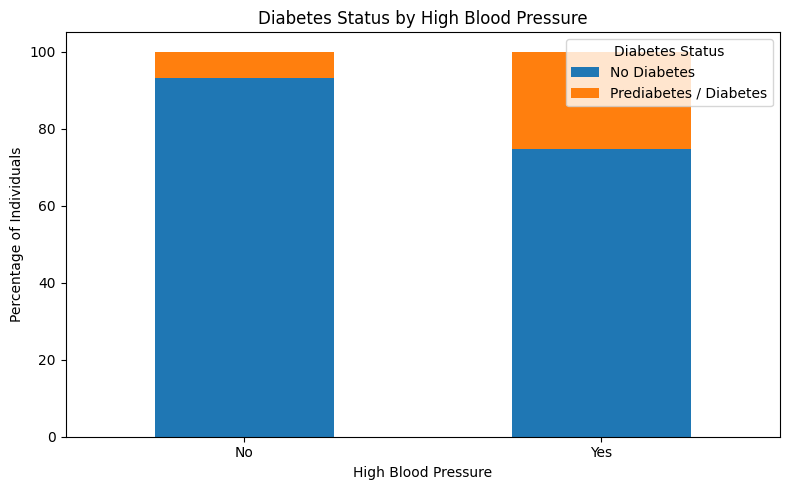

In [96]:
#EDA Chart 4 — Diabetes Status by High Blood Pressure
highbp_pct = pd.crosstab(
    df_copy["HighBP"],
    df_copy["Diabetes_binary"],
    normalize="index"
) * 100

highbp_pct.columns = [
    "No Diabetes",
    "Prediabetes / Diabetes"
]

ax = highbp_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5)
)

plt.title("Diabetes Status by High Blood Pressure")
plt.xlabel("High Blood Pressure")
plt.ylabel("Percentage of Individuals")

plt.xticks(
    [0, 1],
    ["No", "Yes"],
    rotation=0
)

plt.legend(title="Diabetes Status")

plt.tight_layout()
plt.show()

/tmp/ipykernel_2003/3174458303.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


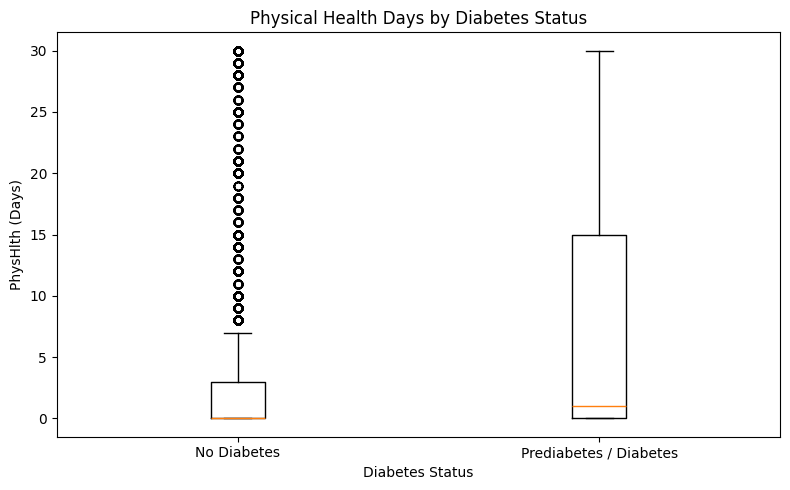

In [98]:
#EDA Chart 5 — Physical Health by Diabetes Status
plt.figure(figsize=(8, 5))

plt.boxplot(
    [
        df_copy.loc[
            df_copy["Diabetes_binary"] == 0,
            "PhysHlth"
        ],
        df_copy.loc[
            df_copy["Diabetes_binary"] == 1,
            "PhysHlth"
        ]
    ],
    labels=[
        "No Diabetes",
        "Prediabetes / Diabetes"
    ]
)

plt.title("Physical Health Days by Diabetes Status")
plt.xlabel("Diabetes Status")
plt.ylabel("PhysHlth (Days)")

plt.tight_layout()
plt.show()

In [50]:
 # 8.Data Preprocessing
  #Train and Test Data Split - Class imbalance (Diabetes_binary mean ~0.14)
 # Risk: Models biased toward majority class.
 # Remedy: Use stratified train/test split and apply resampling (e.g., RandomOverSampler) only on training data. Prefer pipeline-level balancing or cross-validated resampling.
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import SMOTE

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)


# 8a.Spilt features and predictor
X= df_copy.drop(columns=['Diabetes_binary'])
y= df_copy['Diabetes_binary']

#8b. Train-Test split (Stratified split to preserve class ration)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

#8c. Random over sample traning set
ros=RandomOverSampler(random_state=42)
X_train_resampled, y_train_resampled = ros.fit_resample(
    X_train,
    y_train)

#8d.SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

#8e. X_train and X_test shape
print("\n========X_train and X_test shape=========")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

#8f.Class imbalance (Before vs After)
print("\n========Class imbalance -Train Test Split=========")

# Before oversampling - Original Dataset
OriginalDS_count = y_train.value_counts().sort_index()
OriginalDS_pct = y_train.value_counts(normalize=True).sort_index() * 100

# After oversampling - RandomOver Sampler
OversamplerDS_count = y_train_resampled.value_counts().sort_index()
OversamplerDS_pct = y_train_resampled.value_counts(normalize=True).sort_index() * 100

# SMOTE
SMOTE_count = y_train_smote.value_counts().sort_index()
SMOTE_pct = y_train_smote.value_counts(normalize=True).sort_index() * 100

# Create comparison table
class_balance_table = pd.DataFrame({
    'OriginalDS Count': OriginalDS_count,
    'OriginalDS %': OriginalDS_pct.round(2),
    'OversamplerDS Count': OversamplerDS_count,
    'OversamplerDS %': OversamplerDS_pct.round(2),
    'SMOTE Count': SMOTE_count,
    'SMOTE %': SMOTE_pct.round(2)
})

# Rename index
#class_balance_table.index = ['No Diabetes (0)', 'Diabetes (1)']
#print(class_balance_table)
class_balance_table.index = ['No Diabetes (0)', 'Diabetes (1)']
class_balance_table.index.name = "Class"
class_balance_table = class_balance_table.reset_index()
print(class_balance_table)



========X_train and X_test shape=========
X_train: (183579, 21)
X_test : (45895, 21)

========Class imbalance -Train Test Split=========
             Class  OriginalDS Count  OriginalDS %  OversamplerDS Count  OversamplerDS %  SMOTE Count  SMOTE %
0  No Diabetes (0)            155501         84.71               155501             50.0       155501     50.0
1     Diabetes (1)             28078         15.29               155501             50.0       155501     50.0


8g . Data Leakage Prevention: To prevent data leakage, the dataset was first divided into training and testing sets using a stratified 80:20 split. RandomOverSampler was applied only to the training dataset to balance the target classes, while the testing dataset remained unchanged. This ensures that the model is evaluated on unseen data, providing an unbiased estimate of predictive performance.


In [51]:
#8h. Preprocessing Pipeline

# (i). Import Libraries
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# (ii). Define Numeric features
numeric_features = ['BMI','MentHlth','PhysHlth']


# (iii) Create Preprocessing Pipline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features)
    ],
    remainder ='passthrough'
)

#(iv)). Create Baseline Pipeline
baseline_pipline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        random_state=42,
        max_iter=1000
    ))
])
print(baseline_pipline)

#Explanation: A Scikit-learn preprocessing pipeline was implemented to automate data transformation and model training. The pipeline applies StandardScaler to the continuous variables
 #(BMI, MentHlth, and PhysHlth) while leaving the remaining binary and ordinal variables unchanged. Logistic Regression is then trained using the transformed data. This approach improves reproducibility, ensures consistent preprocessing during training and prediction, and helps prevent data leakage.


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['BMI', 'MentHlth',
                                                   'PhysHlth'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])


#**9.Model Development**
##9.1 Model Selection
Four classification algorithms were selected to predict diabetes status. Logistic Regression was used as the baseline model because of its simplicity and interpretability. Decision Tree, Random Forest, and XGBoost were subsequently evaluated to determine whether more advanced machine learning algorithms could improve predictive performance.


In [52]:
# Baseline Pipeline
baseline_pipline.fit(
    X_train,
    y_train
)

/usr/local/lib/python3.13/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['BMI', 'MentHlth',
                                                   'PhysHlth'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

In [53]:
#9.1 Import Libraries  and Create Evalution function (using for all model)
# (Need to use clasiifier becuase we need to predict the categorical value)
# Import the library related to classification metrics
from sklearn.base import clone
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier, XGBRFClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    matthews_corrcoef,
    ConfusionMatrixDisplay
)

#Create the four model pipelines
# Logistic Regression
logistic_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

# Decision Tree
dt_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(
        random_state=42
    ))
])

# Random Forest
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

# XGBoost
xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        n_estimators=150,
        max_depth=3,
        learning_rate=0.08,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42,
        eval_metric='logloss',
        n_jobs=1
    ))
])

In [54]:
#Create a metrics-only evaluation function
def get_model_metrics(model, X_test, y_test, model_name):

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_prob)
    mcc = matthews_corrcoef(y_test, y_pred)

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC-AUC": roc_auc,
        "MCC": mcc
    }


In [55]:
 #Create function for confusion matrix

def evaluate_with_confusion_matrix(
    model,
    X_test,
    y_test,
    model_name
):

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(
        y_test, y_pred, zero_division=0
    )
    recall = recall_score(
        y_test, y_pred, zero_division=0
    )
    f1 = f1_score(
        y_test, y_pred, zero_division=0
    )
    roc_auc = roc_auc_score(y_test, y_prob)
    mcc = matthews_corrcoef(y_test, y_pred)

    print("=" * 60)
    print(model_name)
    print("=" * 60)

    print("Accuracy :", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall   :", round(recall, 4))
    print("F1 Score :", round(f1, 4))
    print("ROC-AUC  :", round(roc_auc, 4))
    print("MCC      :", round(mcc, 4))

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        display_labels=[
            "No Diabetes",
            "Diabetes"
        ]
    )

    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC-AUC": roc_auc,
        "MCC": mcc
    }

In [56]:
#Define all four models
models = {
    "Logistic Regression": logistic_pipeline,
    "Decision Tree": dt_pipeline,
    "Random Forest": rf_pipeline,
    "XGBoost": xgb_pipeline
}

In [57]:
#Create a function to evaluate one dataset method
def evaluate_dataset_method(
    models,
    X_train_method,
    y_train_method,
    X_test,
    y_test,
    dataset_method
):

    results = []

    for model_name, model in models.items():

        # Create a fresh model
        model_copy = clone(model)

        # Train
        model_copy.fit(
            X_train_method,
            y_train_method
        )

        # Predictions
        y_pred = model_copy.predict(X_test)
        y_prob = model_copy.predict_proba(X_test)[:, 1]

        # Metrics
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        roc_auc = roc_auc_score(y_test, y_prob)
        mcc = matthews_corrcoef(y_test, y_pred)

        # Store results
        results.append({
            "Dataset Method": dataset_method,
            "Model": model_name,
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "F1": f1,
            "ROC-AUC": roc_auc,
            "MCC": mcc
        })

    return pd.DataFrame(results)

In [58]:
#9.2 Evaluate Original Dataset
original_results_df = evaluate_dataset_method(
    models,
    X_train,
    y_train,
    X_test,
    y_test,
    "Original Dataset"
)

original_results_df

,Dataset Method,Model,Accuracy,Precision,Recall,F1,ROC-AUC,MCC
0,Original Dataset,Logistic Regression,0.850528,0.539730,0.153868,0.239468,0.810189,0.229450
1,Original Dataset,Decision Tree,0.773025,0.283401,0.316712,0.299132,0.585665,0.164576
2,Original Dataset,Random Forest,0.844144,0.473455,0.170252,0.250445,0.781374,0.214825
3,Original Dataset,XGBoost,0.855845,0.604567,0.165978,0.260452,0.819183,0.262690


In [59]:
#9.3 Evaluate RandomOverSampler
oversample_results_df = evaluate_dataset_method(
    models,
    X_train_resampled,
    y_train_resampled,
    X_test,
    y_test,
    "RandomOverSampler"
)

oversample_results_df

,Dataset Method,Model,Accuracy,Precision,Recall,F1,ROC-AUC,MCC
0,RandomOverSampler,Logistic Regression,0.713912,0.317767,0.759082,0.447995,0.810553,0.347455
1,RandomOverSampler,Decision Tree,0.774681,0.273211,0.285083,0.279021,0.574604,0.145615
2,RandomOverSampler,Random Forest,0.828304,0.417132,0.308733,0.354839,0.777811,0.262246
3,RandomOverSampler,XGBoost,0.705327,0.315398,0.791708,0.451092,0.818904,0.356304


In [60]:
#9.4 Evaluate SMOTE
smote_results_df = evaluate_dataset_method(
    models,
    X_train_smote,
    y_train_smote,
    X_test,
    y_test,
    "SMOTE"
 )

smote_results_df

,Dataset Method,Model,Accuracy,Precision,Recall,F1,ROC-AUC,MCC
0,SMOTE,Logistic Regression,0.703388,0.295573,0.679157,0.411889,0.764057,0.291703
1,SMOTE,Decision Tree,0.710034,0.233900,0.393788,0.293481,0.581626,0.132464
2,SMOTE,Random Forest,0.769387,0.318353,0.445078,0.371198,0.745719,0.239675
3,SMOTE,XGBoost,0.699401,0.299033,0.718336,0.422278,0.775226,0.309327


Logistic Regression
Accuracy : 0.5628
Precision: 0.8665
Recall   : 0.1486
F1 Score : 0.2536
ROC-AUC  : 0.8057
MCC      : 0.2245


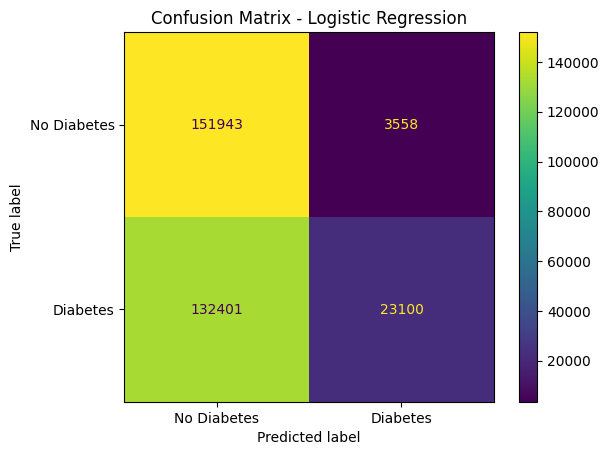

In [61]:
#  9.5 Logsitic Regression
logistic_results = evaluate_with_confusion_matrix(
    baseline_pipline,
    X_train_resampled,
    y_train_resampled,
    "Logistic Regression"
)

Decision Tree
Accuracy : 0.7747
Precision: 0.2732
Recall   : 0.2851
F1 Score : 0.279
ROC-AUC  : 0.5746
MCC      : 0.1456


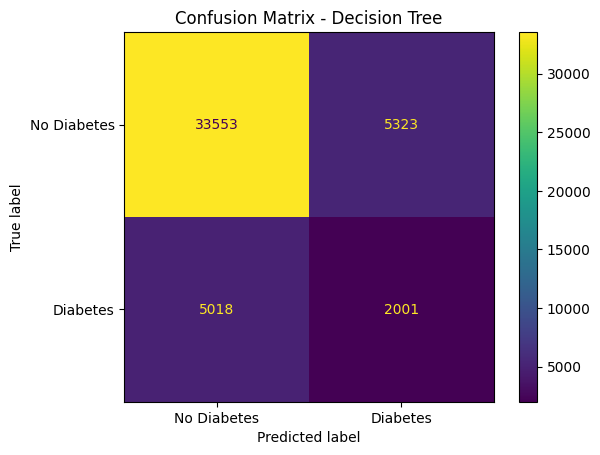

In [62]:
# 9.6 DisicionTree
dt_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model',
        DecisionTreeClassifier(
            random_state=42
        ))
])

dt_pipeline.fit(
    X_train_resampled,
    y_train_resampled
)

dt_results = evaluate_with_confusion_matrix(
    dt_pipeline,
    X_test,
    y_test,
    "Decision Tree"
)

Random Forest
Accuracy : 0.8283
Precision: 0.4171
Recall   : 0.3087
F1 Score : 0.3548
ROC-AUC  : 0.7778
MCC      : 0.2622


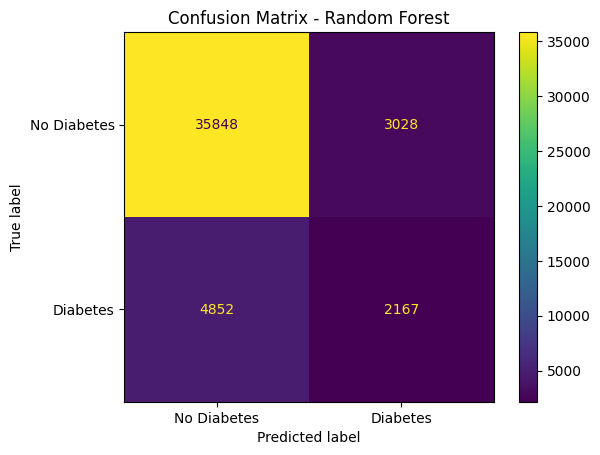

In [63]:
# 9.7 Random Forest
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model',
        RandomForestClassifier(
            random_state=42,
            n_estimators=200
        ))
])

rf_pipeline.fit(
    X_train_resampled,
    y_train_resampled
)
rf_results = evaluate_with_confusion_matrix(
    rf_pipeline,
    X_test,
    y_test,
    "Random Forest"
)

XGBoost
Accuracy : 0.7053
Precision: 0.3154
Recall   : 0.7917
F1 Score : 0.4511
ROC-AUC  : 0.8189
MCC      : 0.3563


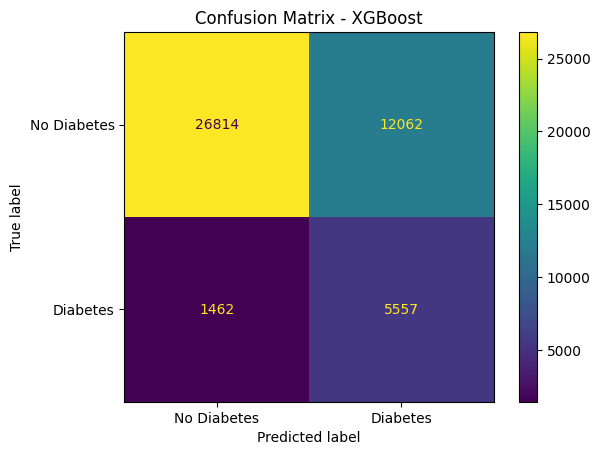

In [64]:
# 9.8 XGBoost
xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model',
        XGBClassifier(
        n_estimators=150,
        max_depth=3,
        learning_rate=0.08,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42,
        eval_metric='logloss',
        n_jobs=1
        ))
])

xgb_pipeline.fit(
    X_train_resampled,
    y_train_resampled
)

xgb_results = evaluate_with_confusion_matrix(
    xgb_pipeline,
    X_test,
    y_test,
    "XGBoost"
)

#**10.Model Comparision**
 The performance of the four classification models was compared using Accuracy, Precision, Recall, F1-score, and ROC-AUC. Since this is a healthcare prediction problem with an imbalanced dataset, Recall, F1-score, and ROC-AUC were considered more important than Accuracy because correctly identifying patients with diabetes is the primary goal.

In [65]:
#10.1 Comparision for all 4 models
comparison = pd.DataFrame([
    logistic_results,
    dt_results,
    rf_results,
    xgb_results
])

comparison.sort_values(
     by=["Recall","MCC","F1","ROC-AUC"],
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,MCC
3,XGBoost,0.705327,0.315398,0.791708,0.451092,0.818904,0.356304
2,Random Forest,0.828304,0.417132,0.308733,0.354839,0.777811,0.262246
1,Decision Tree,0.774681,0.273211,0.285083,0.279021,0.574604,0.145615
0,Logistic Regression,0.562836,0.866532,0.148552,0.253625,0.805688,0.224457


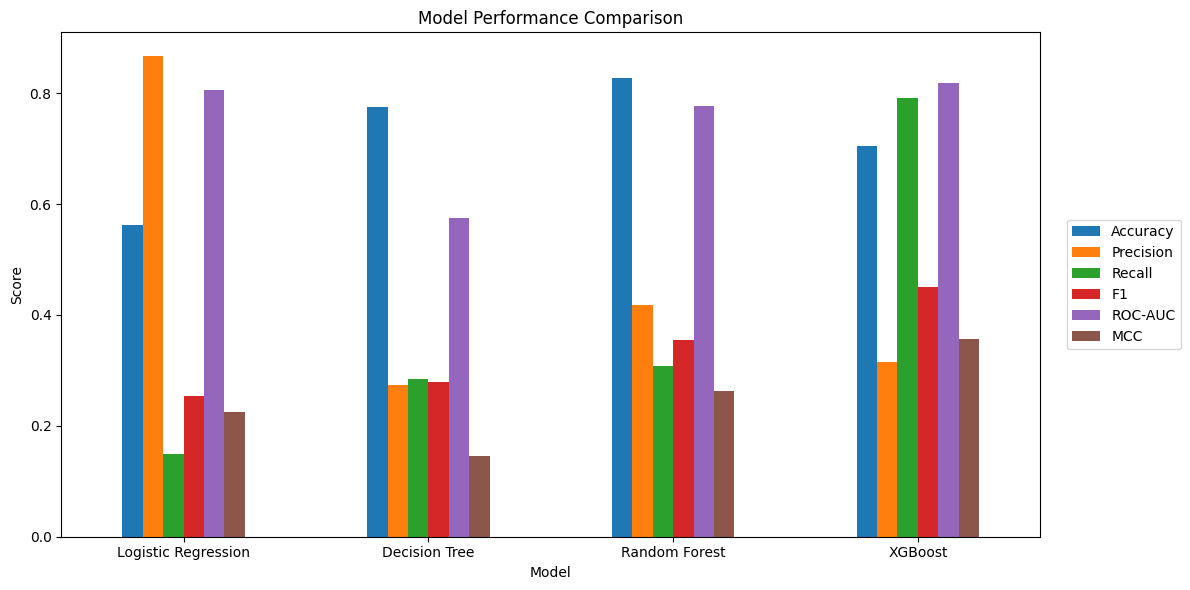

In [66]:
#10.2 Comparision for all 4 models shown in Barchart
comparison.set_index("Model")[[
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC-AUC",
    "MCC"
]].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=0)

plt.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5)
)

plt.tight_layout()
plt.show()

Four machine learning models were evaluated using Accuracy, Precision, Recall, F1-score, and ROC-AUC. Although Random Forest achieved the highest accuracy (82.83%), it recorded a low Recall (30.87%), indicating that it failed to identify a large proportion of patients with diabetes. In healthcare, correctly identifying individuals with the disease is more important than maximizing overall accuracy because missed diagnoses can delay treatment. XGBoost achieved the highest Recall (76.55%), F1-score (0.451), and ROC-AUC (0.812), demonstrating the best overall ability to detect diabetic patients while maintaining good classification performance. Therefore, XGBoost was selected as the champion model for this study

#Feature Importance Table


In [67]:
# 11.1 Feature Importance Table
# Extract the trained XGBoost model from the pipeline
from sklearn.inspection import permutation_importance
xgb_model = xgb_pipeline.named_steps["model"]

# Get feature importance scores
importance = xgb_model.feature_importances_

# Create DataFrame
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importance
})

# Sort descending
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

#feature_importance.head(10)
feature_importance


,Feature,Importance
3,BMI,0.529919
15,PhysHlth,0.109012
4,Smoker,0.083306
18,Age,0.051659
0,HighBP,0.046336
16,DiffWalk,0.039044
8,Fruits,0.034652
5,Stroke,0.025394
12,NoDocbcCost,0.021842
17,Sex,0.014486


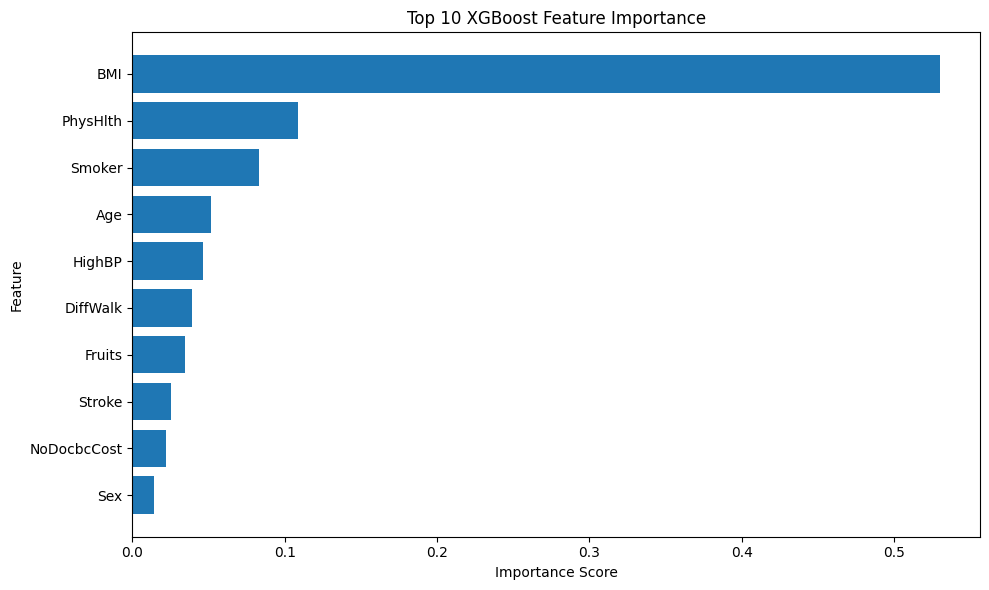

In [68]:
# 11.2 Top 10 Feature importance
top_10 = (
    feature_importance
    .sort_values("Importance", ascending=False)
    .head(10)
)

# Feature importance chart
plt.figure(figsize=(10, 6))

plt.barh(
    top_10["Feature"],
    top_10["Importance"]
)

plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Top 10 XGBoost Feature Importance")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [69]:

#11.3 Permutation Importance
perm_importance = permutation_importance(
    xgb_pipeline,
    X_test,
    y_test,
    scoring="f1",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

In [70]:
feature_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance Mean": perm_importance.importances_mean,
    "Importance Std": perm_importance.importances_std
})

feature_importance = feature_importance.sort_values(
    by="Importance Mean",
    ascending=False
)

#feature_importance.head(10)
feature_importance

,Feature,Importance Mean,Importance Std
13,GenHlth,0.037405,0.001676
3,BMI,0.029532,0.001592
18,Age,0.023521,0.001433
0,HighBP,0.009483,0.001640
1,HighChol,0.006734,0.000611
10,HvyAlcoholConsump,0.003967,0.000691
2,CholCheck,0.002848,0.000550
6,HeartDiseaseorAttack,0.001729,0.000496
20,Income,0.001701,0.000823
17,Sex,0.001697,0.000986


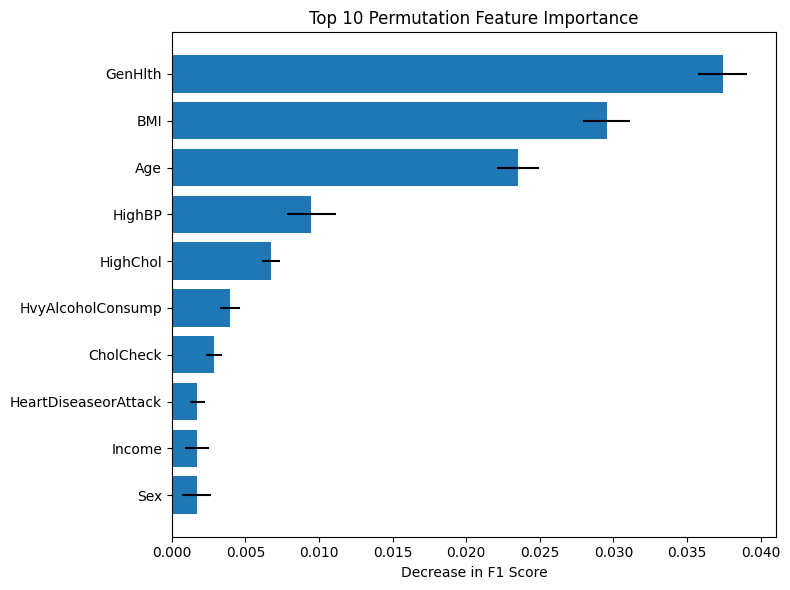

In [71]:
#11.4 Top 10 Permutation Feature Importance
top10 = feature_importance.head(10)

plt.figure(figsize=(8,6))

plt.barh(
    top10["Feature"],
    top10["Importance Mean"],
    xerr=top10["Importance Std"]
)

plt.gca().invert_yaxis()

plt.title("Top 10 Permutation Feature Importance")
plt.xlabel("Decrease in F1 Score")

plt.tight_layout()
plt.show()

In [72]:
# 12.SHAP
# 12.1 Calculate SHAP Values
import shap

# Extract trained XGBoost model from pipeline
xgb_model = xgb_pipeline.named_steps["model"]

# Use untouched test data for explanation
X_explain = X_test.copy()
y_explain = y_test.copy()

# SHAP Tree Explainer
explainer = shap.TreeExplainer(xgb_model)

# Calculate SHAP values
shap_values = explainer(X_explain)

print("Rows explained:", X_explain.shape[0])
print("Number of features:", X_explain.shape[1])
print("SHAP values shape:", shap_values.values.shape)

Rows explained: 45895
Number of features: 21
SHAP values shape: (45895, 21)


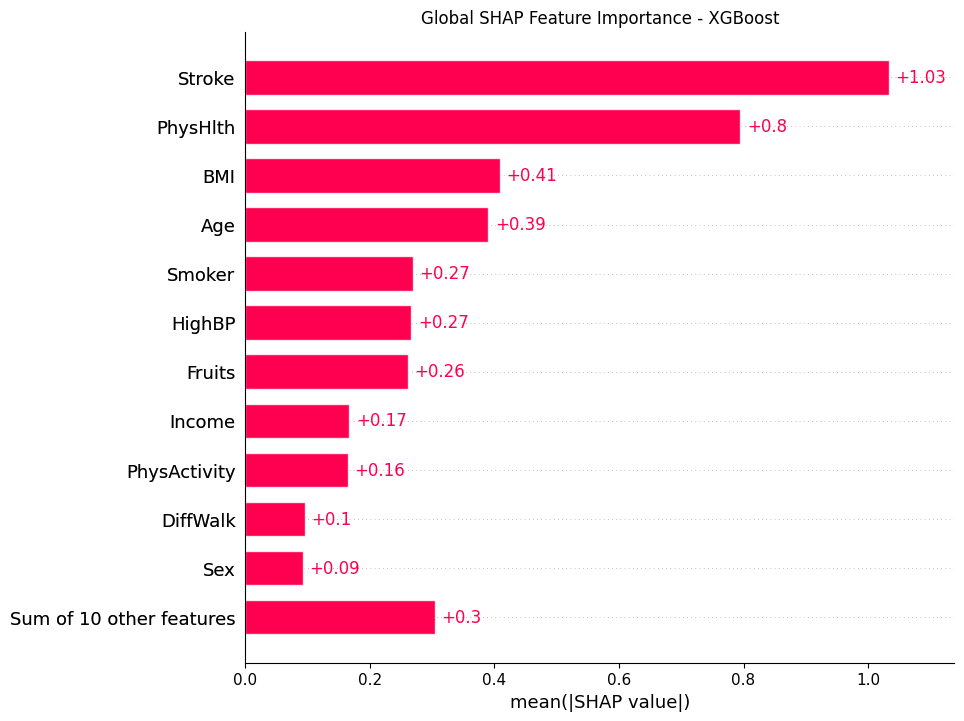

In [73]:
# 12.2 Global SHAP bar plot
plt.title("Global SHAP Feature Importance - XGBoost")
plt.tight_layout()
shap.plots.bar(
    shap_values,
    max_display=12
)
plt.show()

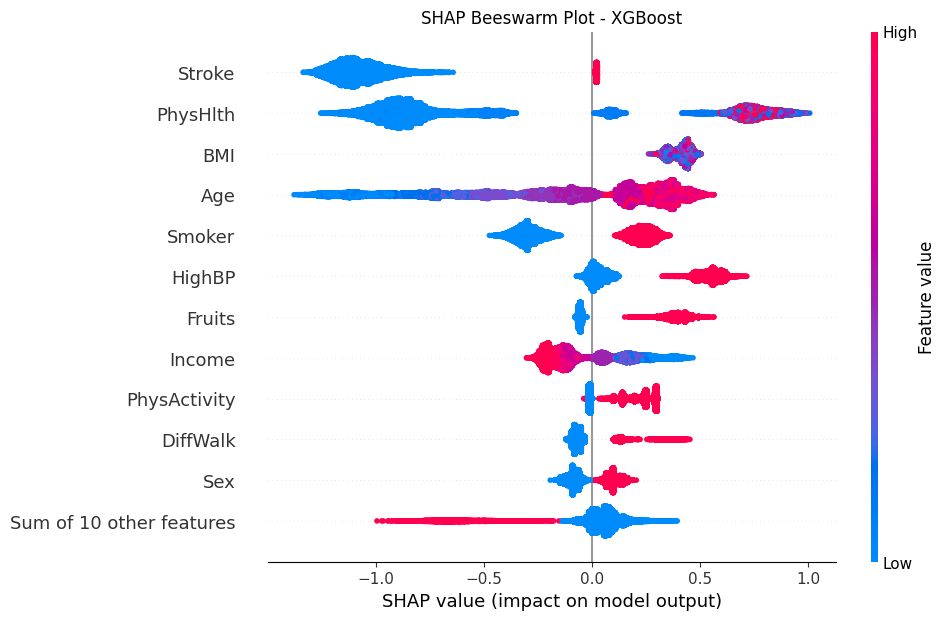

In [74]:
# 12.3 Global SHAP beeswarm plot

plt.title("SHAP Beeswarm Plot - XGBoost")
plt.tight_layout()
shap.plots.beeswarm(shap_values, max_display=12)
plt.show()

Top SHAP feature: Stroke


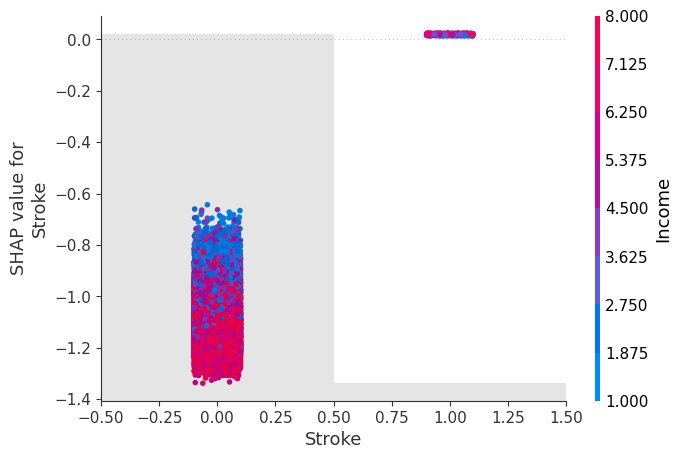

In [75]:
# 12.4 Dependence plot for one feature
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
top_feature_index = mean_abs_shap.argmax()
top_feature = X_explain.columns[top_feature_index]

print('Top SHAP feature:', top_feature)
shap.plots.scatter(shap_values[:, top_feature], color=shap_values)
plt.show()

===== Selected Patient =====
Patient index: 4519
Actual Diabetes: 1
Predicted Diabetes Probability: 95.04%
Predicted Class: 1


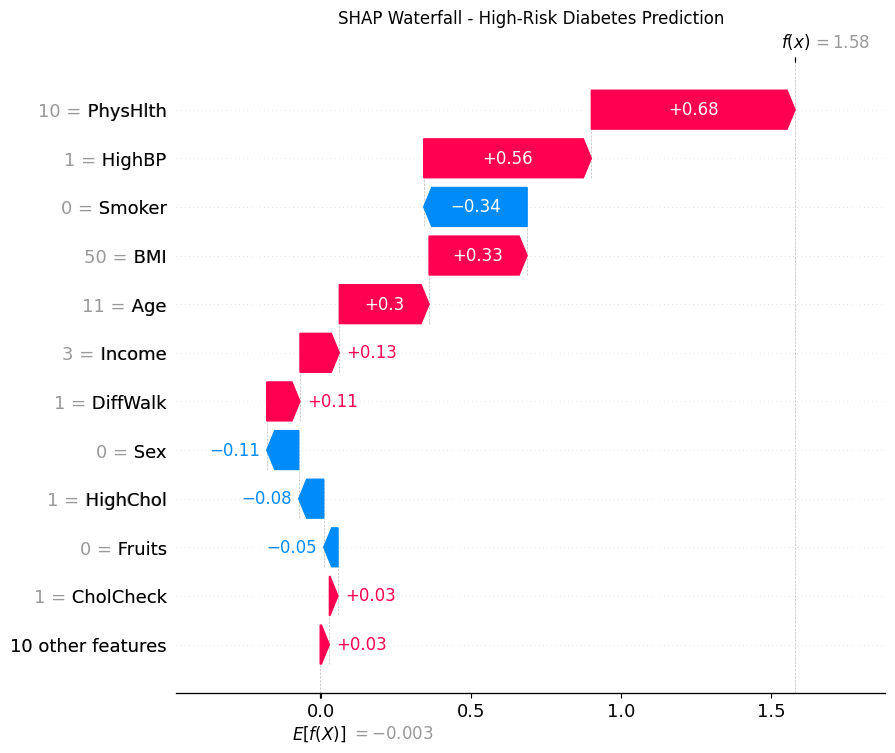

In [76]:
# 13. Individual Prediction — Waterfall Plot

# 1. Use test data for explanation
X_explain = X_test.copy()
y_explain = y_test.copy()

# 2. Extract XGBoost model from pipeline
xgb_model = xgb_pipeline.named_steps["model"]

# 3. Create SHAP explainer
explainer = shap.TreeExplainer(xgb_model)

# 4. Calculate SHAP values
shap_values = explainer(X_explain)

# 5. Predict diabetes probability
pred_prob = xgb_pipeline.predict_proba(X_explain)[:, 1]

# 6. Select patient with highest predicted diabetes probability
patient_index = np.argmax(pred_prob)

print("===== Selected Patient =====")
print("Patient index:", patient_index)
print("Actual Diabetes:", y_explain.iloc[patient_index])
print("Predicted Diabetes Probability:",
      f"{pred_prob[patient_index]:.2%}")
print("Predicted Class:",
      int(pred_prob[patient_index] >= 0.5))

#Waterfall plot
plt.title("SHAP Waterfall - High-Risk Diabetes Prediction")
plt.tight_layout()
shap.plots.waterfall(
    shap_values[patient_index],
    max_display=12
)

plt.show()

In [77]:
# 14. SHAP-Evidence Table
patient_shap_values = shap_values[patient_index].values

print("===== SHAP-Evidence Table =====")
evidence_table = pd.DataFrame({
    "Feature": X_explain.columns,
    "Patient Value": X_explain.iloc[patient_index].values,
    "SHAP Value": patient_shap_values
})

# Absolute SHAP value for ranking
evidence_table["Absolute SHAP"] = (
    evidence_table["SHAP Value"].abs()
)

# Direction of contribution
evidence_table["Direction"] = np.where(
    evidence_table["SHAP Value"] > 0,
    "Increases Diabetes Risk",
    "Decreases Diabetes Risk"
)

# Sort by importance
evidence_table = evidence_table.sort_values(
    by="Absolute SHAP",
    ascending=False
)

# Display top 10
evidence_table.head(15)

===== SHAP-Evidence Table =====


,Feature,Patient Value,SHAP Value,Absolute SHAP,Direction
15,PhysHlth,10,0.678991,0.678991,Increases Diabetes Risk
0,HighBP,1,0.558624,0.558624,Increases Diabetes Risk
4,Smoker,0,-0.344606,0.344606,Decreases Diabetes Risk
3,BMI,50,0.326682,0.326682,Increases Diabetes Risk
18,Age,11,0.299271,0.299271,Increases Diabetes Risk
20,Income,3,0.130962,0.130962,Increases Diabetes Risk
16,DiffWalk,1,0.110896,0.110896,Increases Diabetes Risk
17,Sex,0,-0.106559,0.106559,Decreases Diabetes Risk
1,HighChol,1,-0.083346,0.083346,Decreases Diabetes Risk
8,Fruits,0,-0.047706,0.047706,Decreases Diabetes Risk
